In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r'C:\Users\upadh\Desktop\da_projs\credit_card_fraud_detection\data\creditcard.csv')

# First look
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (284807, 31)

Column names:
 ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Check data types and nulls
print(df.info())

# Check for missing values
print("\nMissing values:\n", df.isnull().sum())

# Basic statistics
print("\nBasic stats:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


C:\Users\upadh\AppData\Local\Temp\ipykernel_19128\184756519.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['steelblue', 'crimson'])


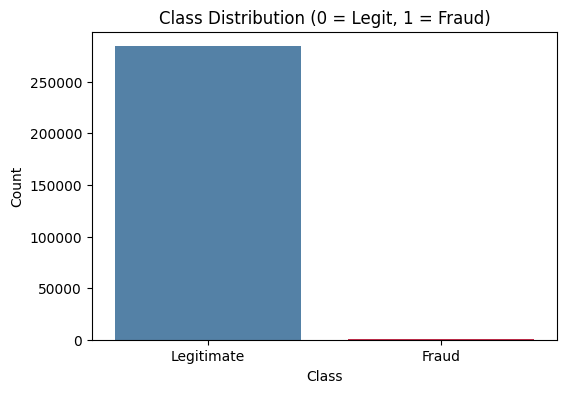

In [6]:
# Class distribution
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"\nFraud percentage: {class_counts[1] / len(df) * 100:.4f}%")

# Visualize
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette=['steelblue', 'crimson'])
plt.title('Class Distribution (0 = Legit, 1 = Fraud)')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.ylabel('Count')
plt.show()

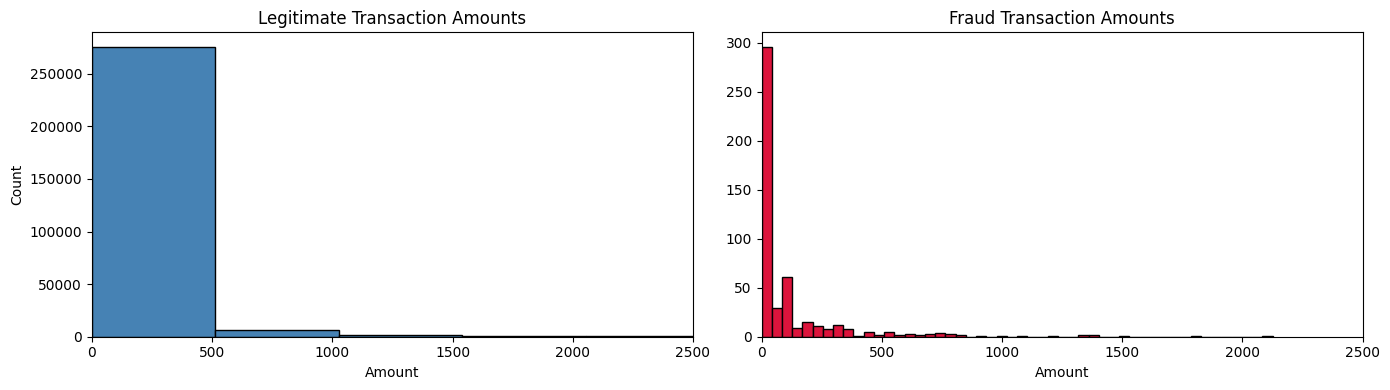

Legitimate - Mean Amount:  88.29
Fraud      - Mean Amount:  122.21


In [8]:
# Compare transaction amounts: fraud vs legitimate
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Legitimate
axes[0].hist(df[df['Class'] == 0]['Amount'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Legitimate Transaction Amounts')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 2500)

# Fraud
axes[1].hist(df[df['Class'] == 1]['Amount'], bins=50, color='crimson', edgecolor='black')
axes[1].set_title('Fraud Transaction Amounts')
axes[1].set_xlabel('Amount')
axes[1].set_xlim(0, 2500)

plt.tight_layout()
plt.show()

# Summary stats
print("Legitimate - Mean Amount: ", df[df['Class']==0]['Amount'].mean().round(2))
print("Fraud      - Mean Amount: ", df[df['Class']==1]['Amount'].mean().round(2))

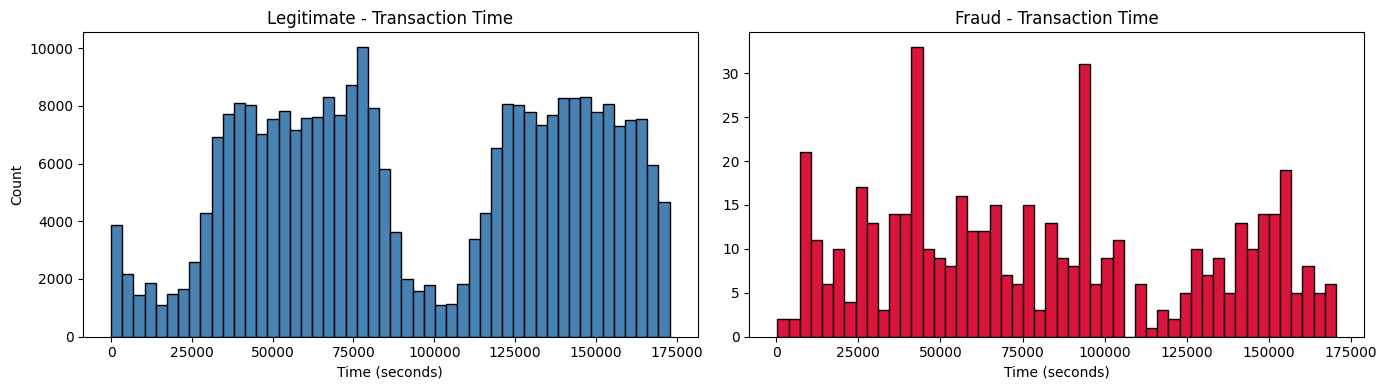

In [9]:
# Compare time of transactions: fraud vs legitimate
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[df['Class'] == 0]['Time'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Legitimate - Transaction Time')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Count')

axes[1].hist(df[df['Class'] == 1]['Time'], bins=50, color='crimson', edgecolor='black')
axes[1].set_title('Fraud - Transaction Time')
axes[1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()

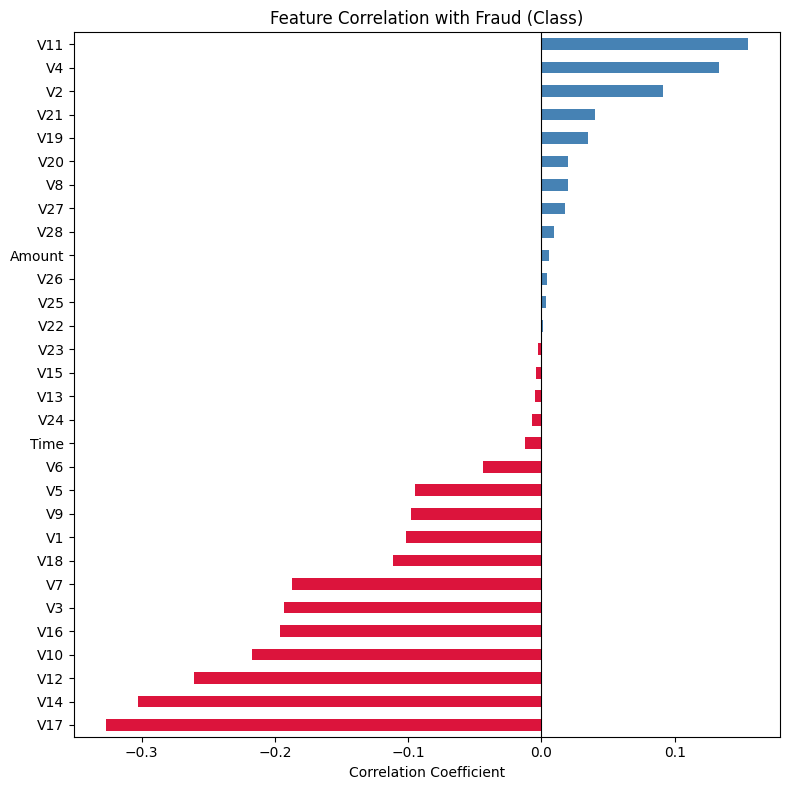

In [10]:
# Correlation of features with fraud
plt.figure(figsize=(8, 5))
correlations = df.corr()['Class'].drop('Class').sort_values()
correlations.plot(kind='barh', color=['crimson' if x < 0 else 'steelblue' for x in correlations], figsize=(8,8))
plt.title('Feature Correlation with Fraud (Class)')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [11]:
from sklearn.preprocessing import StandardScaler

# Amount and Time are the only non-PCA features, they need scaling
# V1-V28 are already scaled from PCA

scaler = StandardScaler()

df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_Scaled'] = scaler.fit_transform(df[['Time']])

# Drop the original unscaled columns
df = df.drop(['Amount', 'Time'], axis=1)

print("Done! New shape:", df.shape)
print(df[['Amount_Scaled', 'Time_Scaled']].head())

Done! New shape: (284807, 31)
   Amount_Scaled  Time_Scaled
0       0.244964    -1.996583
1      -0.342475    -1.996583
2       1.160686    -1.996562
3       0.140534    -1.996562
4      -0.073403    -1.996541


In [12]:
# X = everything except the target column
# y = just the target column (Class)

X = df.drop('Class', axis=1)
y = df['Class']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFraud cases in y:", y.sum())
print("Legitimate cases in y:", (y == 0).sum())

X shape: (284807, 30)
y shape: (284807,)

Fraud cases in y: 492
Legitimate cases in y: 284315


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 20% for testing
    random_state=42,     # reproducibility
    stratify=y           # maintain fraud ratio in both splits
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nFraud in training set:", y_train.sum())
print("Fraud in test set:", y_test.sum())

Training set size: (227845, 30)
Test set size: (56962, 30)

Fraud in training set: 394
Fraud in test set: 98


In [14]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on training data — NEVER on test data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"  Legitimate: {(y_train == 0).sum()}")
print(f"  Fraud:      {y_train.sum()}")

print("\nAfter SMOTE:")
print(f"  Legitimate: {(y_train_smote == 0).sum()}")
print(f"  Fraud:      {y_train_smote.sum()}")

Before SMOTE:
  Legitimate: 227451
  Fraud:      394

After SMOTE:
  Legitimate: 227451
  Fraud:      227451


In [15]:
from sklearn.ensemble import RandomForestClassifier
import time

# Build the model
rf_model = RandomForestClassifier(
    n_estimators=100,      # 100 decision trees
    random_state=42,       # reproducibility
    n_jobs=-1              # use all CPU cores to speed up training
)

# Train it — this may take 1-2 minutes
print("Training model...")
start = time.time()
rf_model.fit(X_train_smote, y_train_smote)
end = time.time()

print(f"Done! Training took {round(end - start, 1)} seconds")

Training model...
Done! Training took 67.9 seconds


In [16]:
# Predict on the test set (data the model has never seen)
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Predictions done!")
print(f"Total test transactions: {len(y_pred)}")
print(f"Predicted as fraud: {y_pred.sum()}")
print(f"Predicted as legitimate: {(y_pred == 0).sum()}")

Predictions done!
Total test transactions: 56962
Predicted as fraud: 97
Predicted as legitimate: 56865


In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962



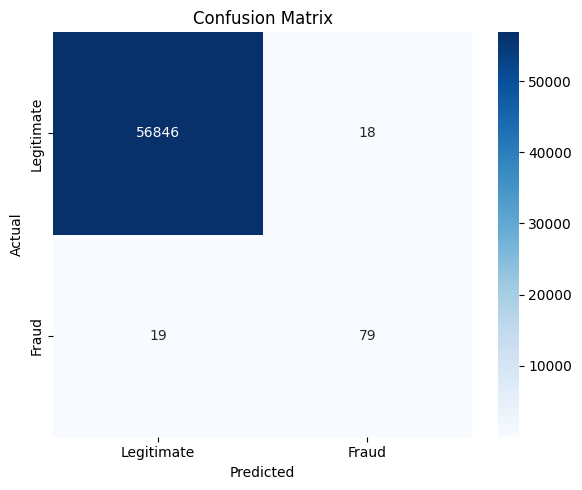

In [18]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

C:\Users\upadh\AppData\Local\Temp\ipykernel_19128\3759632069.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='coolwarm')


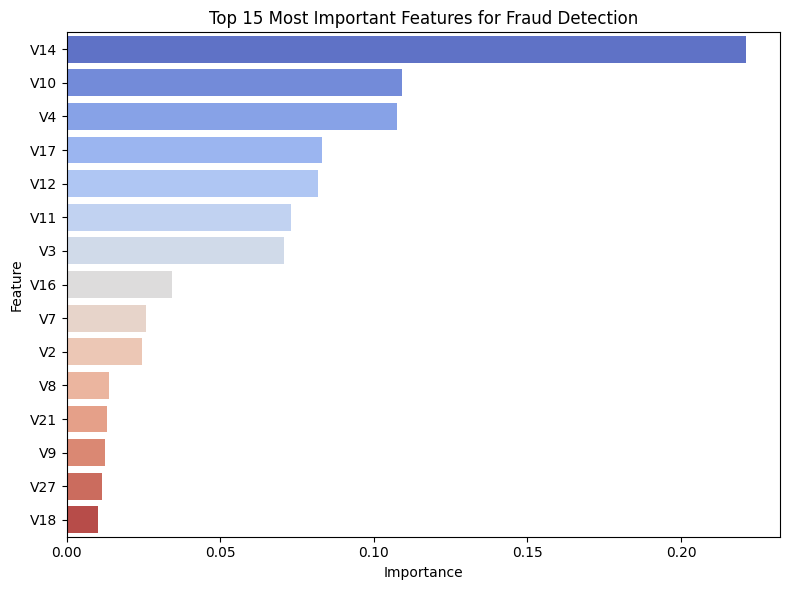

   Feature  Importance
13     V14    0.221167
9      V10    0.109198
3       V4    0.107600
16     V17    0.083030
11     V12    0.081767
10     V11    0.073116
2       V3    0.070656
15     V16    0.034398
6       V7    0.025792
1       V2    0.024697
7       V8    0.013977
20     V21    0.013102
8       V9    0.012461
26     V27    0.011689
17     V18    0.010391


In [19]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='coolwarm')
plt.title('Top 15 Most Important Features for Fraud Detection')
plt.tight_layout()
plt.show()

print(feature_importance)

In [20]:
import joblib

# Save the trained model so you don't have to retrain it every time
joblib.dump(rf_model, '../fraud_detection_model.pkl')
print("Model saved successfully!")

# To load it later:
# model = joblib.load('../fraud_detection_model.pkl')

Model saved successfully!
